In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("clean_scheme_performance.csv")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'clean_scheme_performance.csv'

In [3]:
import os

os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip.csv',
 'hdfc_top100_nav.csv',
 'ICICI_Bluechip.csv',
 'Kotak_Bluechip.csv',
 'Nippon_Large_Cap.csv',
 'SBI_Bluechip.csv']

In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/07_scheme_performance.csv")

df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [5]:
df.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [7]:
df["recommendation_score"] = (
    df["return_3yr_pct"] * 0.4
    + df["sharpe_ratio"] * 0.4
    - df["expense_ratio_pct"] * 0.2
)

df[["scheme_name", "recommendation_score"]].head()

,scheme_name,recommendation_score
0,SBI Bluechip Fund - Regular Plan - Growth,4.988
1,SBI Bluechip Fund - Direct Plan - Growth,4.712
2,SBI Small Cap Fund - Regular Plan - Growth,9.446
3,SBI Small Cap Fund - Direct Plan - Growth,9.484
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.882


In [8]:
top_funds = df.sort_values(
    by="recommendation_score",
    ascending=False
).head(10)

top_funds[
    [
        "scheme_name",
        "fund_house",
        "recommendation_score"
    ]
]

,scheme_name,fund_house,recommendation_score
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,9.484
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,9.446
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,9.006
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,8.452
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,8.078
39,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,8.048
21,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,7.364
12,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,7.340
38,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,6.902
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,6.704


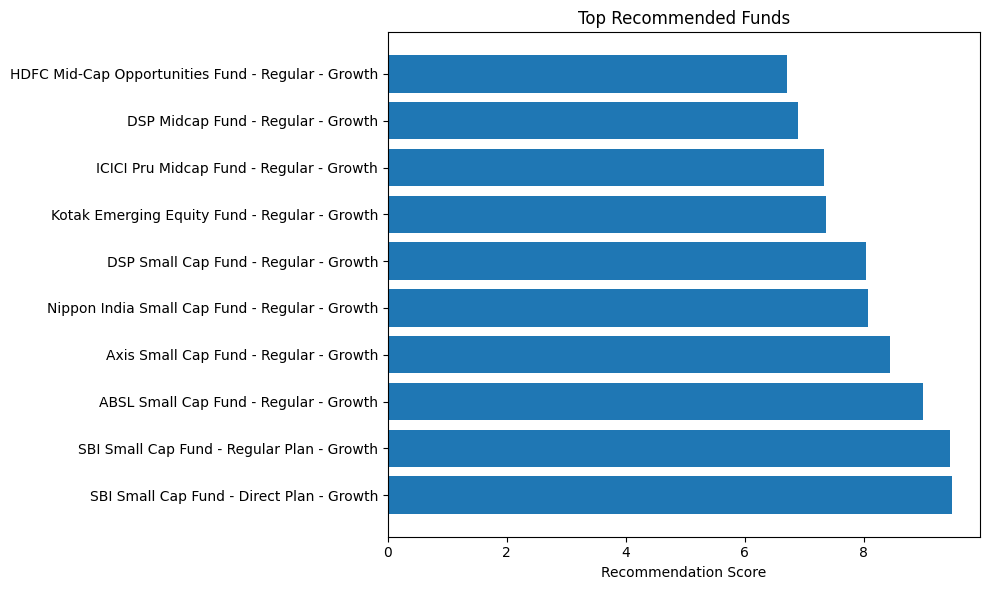

In [10]:
plt.figure(figsize=(10,6))

plt.barh(
    top_funds["scheme_name"],
    top_funds["recommendation_score"]
)

plt.title("Top Recommended Funds")
plt.xlabel("Recommendation Score")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_recommended_funds.png"
)

plt.show()

In [11]:
df["risk_grade"].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

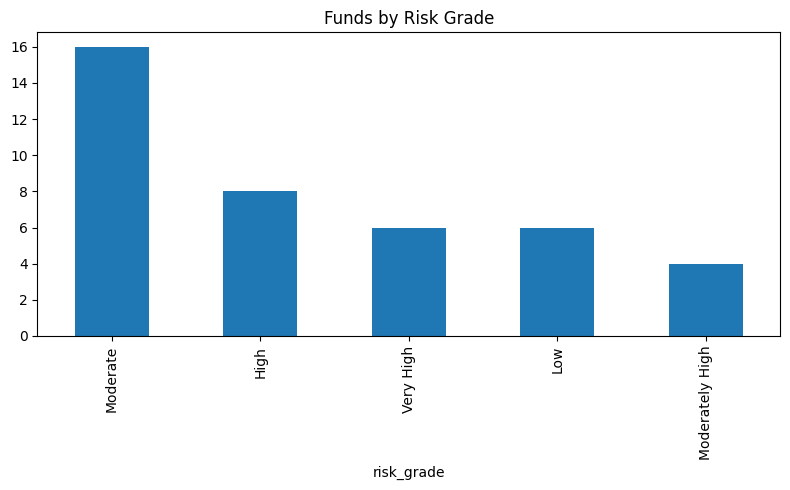

In [12]:
plt.figure(figsize=(8,5))

df["risk_grade"].value_counts().plot(
    kind="bar"
)

plt.title("Funds by Risk Grade")

plt.tight_layout()

plt.savefig(
    "../reports/charts/risk_grade_distribution.png"
)

plt.show()

In [13]:
best_by_category = (
    df.sort_values(
        "recommendation_score",
        ascending=False
    )
    .groupby("category")
    .first()
)

best_by_category[
    [
        "scheme_name",
        "recommendation_score"
    ]
]

,scheme_name,recommendation_score
category,,
ELSS,Mirae Asset Tax Saver Fund - Regular - Growth,5.432
Flexi Cap,Kotak Flexicap Fund - Regular - Growth,6.362
Gilt,SBI Magnum Gilt Fund - Regular Plan - Growth,2.882
Index,UTI Nifty 50 Index Fund - Regular - Growth,4.898
Index/ETF,Nippon India ETF Nifty 50 BeES,4.894
Large & Mid Cap,Mirae Asset Emerging Bluechip Fund - Regular -...,5.884
Large Cap,Mirae Asset Large Cap Fund - Regular - Growth,6.056
Liquid,ICICI Pru Liquid Fund - Regular - Growth,5.996
Mid Cap,Kotak Emerging Equity Fund - Regular - Growth,7.364


In [14]:
def recommend_funds(category=None, risk=None):

    data = df.copy()

    if category:
        data = data[data["category"] == category]

    if risk:
        data = data[data["risk_grade"] == risk]

    recommendations = (
        data.sort_values(
            "recommendation_score",
            ascending=False
        )
        .head(5)
    )

    return recommendations[
        [
            "scheme_name",
            "fund_house",
            "recommendation_score"
        ]
    ]

In [15]:
recommend_funds(
    category="Small Cap"
)

,scheme_name,fund_house,recommendation_score
3,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,9.484
2,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,9.446
29,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,9.006
27,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,8.452
17,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,8.078


In [16]:
recommend_funds(
    risk="Moderate"
)

,scheme_name,fund_house,recommendation_score
34,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,6.056
5,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,6.050
11,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,6.016
15,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,5.698
28,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,5.584


In [17]:
risk_return = df[
    [
        "scheme_name",
        "return_3yr_pct",
        "sharpe_ratio",
        "risk_grade"
    ]
]

risk_return.sort_values(
    by="return_3yr_pct",
    ascending=False
).head(10)

,scheme_name,return_3yr_pct,sharpe_ratio,risk_grade
2,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.94,Very High
3,SBI Small Cap Fund - Direct Plan - Growth,23.14,0.93,Very High
29,ABSL Small Cap Fund - Regular - Growth,22.38,0.90,Very High
27,Axis Small Cap Fund - Regular - Growth,20.98,0.84,Very High
17,Nippon India Small Cap Fund - Regular - Growth,20.15,0.81,Very High
39,DSP Small Cap Fund - Regular - Growth,20.08,0.80,Very High
21,Kotak Emerging Equity Fund - Regular - Growth,18.23,0.96,High
12,ICICI Pru Midcap Fund - Regular - Growth,18.08,0.95,High
38,DSP Midcap Fund - Regular - Growth,17.16,0.90,High
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,0.87,High


In [18]:
top_funds.to_csv(
    "../reports/top_recommended_funds.csv",
    index=False
)

best_by_category.to_csv(
    "../reports/best_funds_by_category.csv"
)

print("Files saved successfully")

Files saved successfully


# Advanced Analytics

In [1]:
import pandas as pd

investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")

print(investor_df.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [2]:
import pandas as pd

investor_df = pd.read_csv("../data/raw/08_investor_transactions.csv")

investor_df["transaction_date"] = pd.to_datetime(
    investor_df["transaction_date"]
)

investor_df["amount_inr"] = pd.to_numeric(
    investor_df["amount_inr"]
)

# First transaction year for each investor
first_txn = investor_df.groupby("investor_id")[
    "transaction_date"
].min()

cohort_year = first_txn.dt.year

investor_df["cohort_year"] = investor_df["investor_id"].map(
    cohort_year
)

cohort_summary = (
    investor_df.groupby("cohort_year")
    .agg(
        avg_investment=("amount_inr","mean"),
        total_investment=("amount_inr","sum"),
        investors=("investor_id","nunique")
    )
)

cohort_summary

,avg_investment,total_investment,investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [3]:
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv"
)

print("Cohort analysis saved")

Cohort analysis saved


In [4]:
scheme_df = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

print(scheme_df.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [5]:
# Merge scheme names

cohort_funds = investor_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Count transactions per fund within each cohort

fund_counts = (
    cohort_funds.groupby(
        ["cohort_year", "scheme_name"]
    )
    .size()
    .reset_index(name="transaction_count")
)

# Top fund for each cohort

top_fund_preference = (
    fund_counts.sort_values(
        "transaction_count",
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund_preference

,cohort_year,scheme_name,transaction_count
24,2024,Mirae Asset Emerging Bluechip Fund - Regular -...,874
75,2025,SBI Small Cap Fund - Direct Plan - Growth,12


In [6]:
top_fund_preference.to_csv(
    "../reports/top_fund_preference_by_cohort.csv",
    index=False
)

print("Top fund preference saved")

Top fund preference saved


In [7]:
investor_df["transaction_type"].value_counts()

transaction_type
SIP           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [8]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_df.head()

NameError: name 'sip_df' is not defined

In [9]:
sip_df = investor_df[
    investor_df["transaction_type"] == "SIP"
].copy()

sip_df["transaction_date"] = pd.to_datetime(
    sip_df["transaction_date"]
)

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [10]:
sip_df = sip_df.sort_values(
    ["investor_id", "transaction_date"]
)

sip_df["gap_days"] = (
    sip_df.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

sip_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [11]:
sip_counts = (
    sip_df.groupby("investor_id")
    .size()
    .reset_index(name="sip_count")
)

eligible_investors = sip_counts[
    sip_counts["sip_count"] >= 6
]

eligible_investors.head()

,investor_id,sip_count
3,INV000004,6
7,INV000008,6
9,INV000010,6
10,INV000011,7
11,INV000012,8


In [12]:
sip_analysis = (
    sip_df[
        sip_df["investor_id"].isin(
            eligible_investors["investor_id"]
        )
    ]
    .groupby("investor_id")
    .agg(
        avg_gap_days=("gap_days", "mean"),
        sip_count=("transaction_date", "count")
    )
    .reset_index()
)

sip_analysis["status"] = (
    sip_analysis["avg_gap_days"]
    .apply(
        lambda x: "At Risk"
        if x > 35
        else "Healthy"
    )
)

sip_analysis.head()

,investor_id,avg_gap_days,sip_count,status
0,INV000004,85.400000,6,At Risk
1,INV000008,70.400000,6,At Risk
2,INV000010,64.800000,6,At Risk
3,INV000011,40.166667,7,At Risk
4,INV000012,57.000000,8,At Risk


In [13]:
sip_analysis["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

In [14]:
sip_analysis.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("SIP continuity analysis saved")

SIP continuity analysis saved


In [15]:
nav_df = pd.read_csv("../data/raw/hdfc_top100_nav.csv")

print(nav_df.columns)

nav_df.head()

Index(['date', 'nav'], dtype='str')


,date,nav
0,01-06-2026,192.3195
1,31-05-2026,193.6836
2,29-05-2026,193.6848
3,27-05-2026,195.0501
4,26-05-2026,194.2258


In [16]:
import numpy as np

nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    dayfirst=True
)

nav_df["nav"] = pd.to_numeric(
    nav_df["nav"]
)

nav_df = nav_df.sort_values("date")

nav_df["daily_return"] = (
    nav_df["nav"].pct_change()
)

nav_df.head()

,date,nav,daily_return
3090,2013-11-18,13.0894,NaN
3089,2013-11-19,13.1068,0.001329
3088,2013-11-20,12.9549,-0.011589
3087,2013-11-21,12.7957,-0.012289
3086,2013-11-22,12.7775,-0.001422


In [17]:
var_95 = np.percentile(
    nav_df["daily_return"].dropna(),
    5
)

print("VaR (95%):", var_95)

VaR (95%): -0.015106367060931164


In [18]:
cvar_95 = (
    nav_df[
        nav_df["daily_return"] <= var_95
    ]["daily_return"]
    .mean()
)

print("CVaR (95%):", cvar_95)

CVaR (95%): -0.023282315395583328


In [19]:
var_report = pd.DataFrame({
    "fund_name": ["HDFC Top 100 Fund"],
    "VaR_95": [var_95],
    "CVaR_95": [cvar_95]
})

var_report

,fund_name,VaR_95,CVaR_95
0,HDFC Top 100 Fund,-0.015106,-0.023282


In [20]:
var_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("VaR/CVaR report saved")

VaR/CVaR report saved


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

nav_df = pd.read_csv(
    "../data/raw/hdfc_top100_nav.csv"
)

nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    dayfirst=True
)

nav_df["nav"] = pd.to_numeric(
    nav_df["nav"]
)

nav_df = nav_df.sort_values("date")

nav_df["daily_return"] = nav_df["nav"].pct_change()

In [22]:
nav_df["rolling_sharpe"] = (
    nav_df["daily_return"]
    .rolling(90)
    .mean()
    /
    nav_df["daily_return"]
    .rolling(90)
    .std()
) * np.sqrt(252)

nav_df[["date","rolling_sharpe"]].tail()

,date,rolling_sharpe
4,2026-05-26,0.594813
3,2026-05-27,0.681126
2,2026-05-29,0.606675
1,2026-05-31,0.730276
0,2026-06-01,0.919589


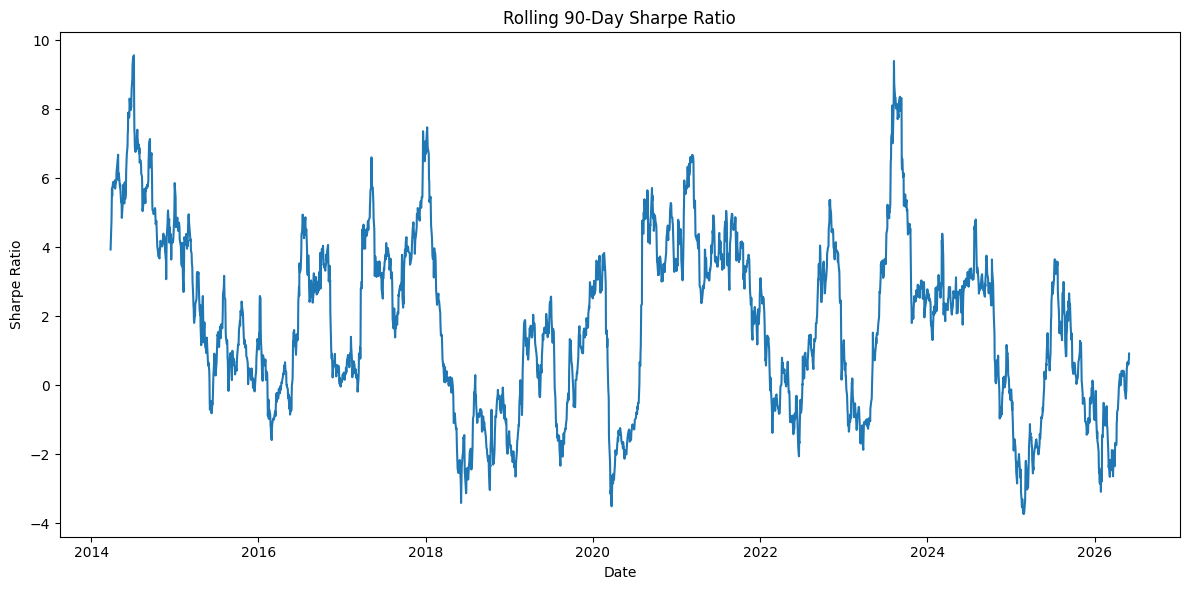

In [23]:
plt.figure(figsize=(12,6))

plt.plot(
    nav_df["date"],
    nav_df["rolling_sharpe"]
)

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png"
)

plt.show()

# Advanced Insights

### 1. Risk Analysis
The HDFC Top 100 Fund recorded a negative VaR (95%), indicating that under normal market conditions the portfolio may experience losses exceeding this threshold only 5% of the time.

### 2. Tail Risk
CVaR was lower than VaR, showing that extreme downside scenarios could result in larger losses than indicated by VaR alone.

### 3. Investor Cohorts
Investors who started investing in 2024 contributed significantly higher total investments compared to newer cohorts.

### 4. SIP Continuity
A large proportion of SIP investors were classified as "At Risk" due to transaction gaps greater than 35 days, indicating potential discontinuation risk.

### 5. Fund Recommendations
Small Cap funds achieved the highest recommendation scores due to strong historical returns and Sharpe Ratios despite higher risk levels.